In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
df = pd.read_csv("Loan_Dataset_1000_rows-v2.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 11)


,Applicant_Name,Gender,Loan_Purpose,Loan_Type,Annual_Income,Loan_Amount_Requested,Loan_Term,Credit_Score,Monthly_Expenses,Outstanding_Debt,Loan_Approval_Status
0,Nikhil Reddy,Male,Study,Secured,2200000,488000,48,756,71600,181000,1
1,Aishwarya Jadhav,Female,Gold,Secured,609000,476000,12,727,28100,202000,0
2,Radhika Singh,Female,Home,Secured,2997000,8751000,180,698,120600,645000,0
3,Kunal Bhat,Male,Gold,Secured,843000,393000,12,900,36900,52000,0
4,Praveen Deshmukh,Male,Personal,Unsecured,504000,261000,24,612,20000,102000,0


In [ ]:
print("Columns:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDataset Information:")
df.info()

Columns:
['Applicant_Name', 'Gender', 'Loan_Purpose', 'Loan_Type', 'Annual_Income', 'Loan_Amount_Requested', 'Loan_Term', 'Credit_Score', 'Monthly_Expenses', 'Outstanding_Debt', 'Loan_Approval_Status']

Missing Values:
Applicant_Name           0
Gender                   0
Loan_Purpose             0
Loan_Type                0
Annual_Income            0
Loan_Amount_Requested    0
Loan_Term                0
Credit_Score             0
Monthly_Expenses         0
Outstanding_Debt         0
Loan_Approval_Status     0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Applicant_Name         1000 non-null   object
 1   Gender                 1000 non-null   object
 2   Loan_Purpose           1000 non-null   object
 3   Loan_Type              1000 non-null   object
 4   Annual_Income          1000 non-

In [ ]:
# Applicant_Name is not useful for predicting loan approval.
df = df.drop("Applicant_Name", axis=1)
print(df.head())

   Gender Loan_Purpose  Loan_Type  Annual_Income  Loan_Amount_Requested  \
0    Male        Study    Secured        2200000                 488000   
1  Female         Gold    Secured         609000                 476000   
2  Female         Home    Secured        2997000                8751000   
3    Male         Gold    Secured         843000                 393000   
4    Male     Personal  Unsecured         504000                 261000   

   Loan_Term  Credit_Score  Monthly_Expenses  Outstanding_Debt  \
0         48           756             71600            181000   
1         12           727             28100            202000   
2        180           698            120600            645000   
3         12           900             36900             52000   
4         24           612             20000            102000   

   Loan_Approval_Status  
0                     1  
1                     0  
2                     0  
3                     0  
4                     

In [ ]:
#

X = df.drop("Loan_Approval_Status", axis=1)
y = df["Loan_Approval_Status"]
print("Features:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)

Features:
['Gender', 'Loan_Purpose', 'Loan_Type', 'Annual_Income', 'Loan_Amount_Requested', 'Loan_Term', 'Credit_Score', 'Monthly_Expenses', 'Outstanding_Debt']

Target:
Loan_Approval_Status


In [ ]:
# Decision Tree also needs numerical input, so categorical columns are converted using one-hot encoding.
X = pd.get_dummies(X, drop_first=True)

print("Encoded Features:")
print(X.head())

print("\nNumber of Features:", X.shape[1])

Encoded Features:
   Annual_Income  Loan_Amount_Requested  Loan_Term  Credit_Score  \
0        2200000                 488000         48           756   
1         609000                 476000         12           727   
2        2997000                8751000        180           698   
3         843000                 393000         12           900   
4         504000                 261000         24           612   

   Monthly_Expenses  Outstanding_Debt  Gender_Male  Loan_Purpose_Card  \
0             71600            181000         True              False   
1             28100            202000        False              False   
2            120600            645000        False              False   
3             36900             52000         True              False   
4             20000            102000         True              False   

   Loan_Purpose_Gold  Loan_Purpose_Home  Loan_Purpose_Personal  \
0              False              False                  False   
1 

In [ ]:
# We use:

# 80% training data
# 20% testing data

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y )
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 13)
Testing data: (200, 13)


In [ ]:
dt_model = DecisionTreeClassifier( random_state=42 )
dt_model.fit(X_train, y_train)
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [ ]:
y_pred = dt_model.predict(X_test)
print("Predictions:")
print(y_pred[:20])

Predictions:
[1 0 0 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 0 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)
print("Decision Tree Accuracy (%):", accuracy * 100)

Decision Tree Accuracy: 0.8
Decision Tree Accuracy (%): 80.0


In [ ]:
print("Classification Report:\n")
print(classification_report( y_test, y_pred, target_names=["Not Approved", "Approved"] ))

Classification Report:

              precision    recall  f1-score   support

Not Approved       0.87      0.86      0.87       152
    Approved       0.58      0.60      0.59        48

    accuracy                           0.80       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.80      0.80      0.80       200



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[131  21]
 [ 19  29]]


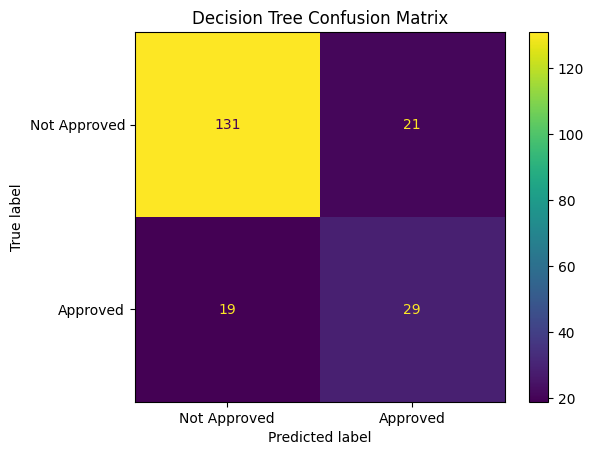

In [ ]:
disp = ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=["Not Approved", "Approved"] )
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

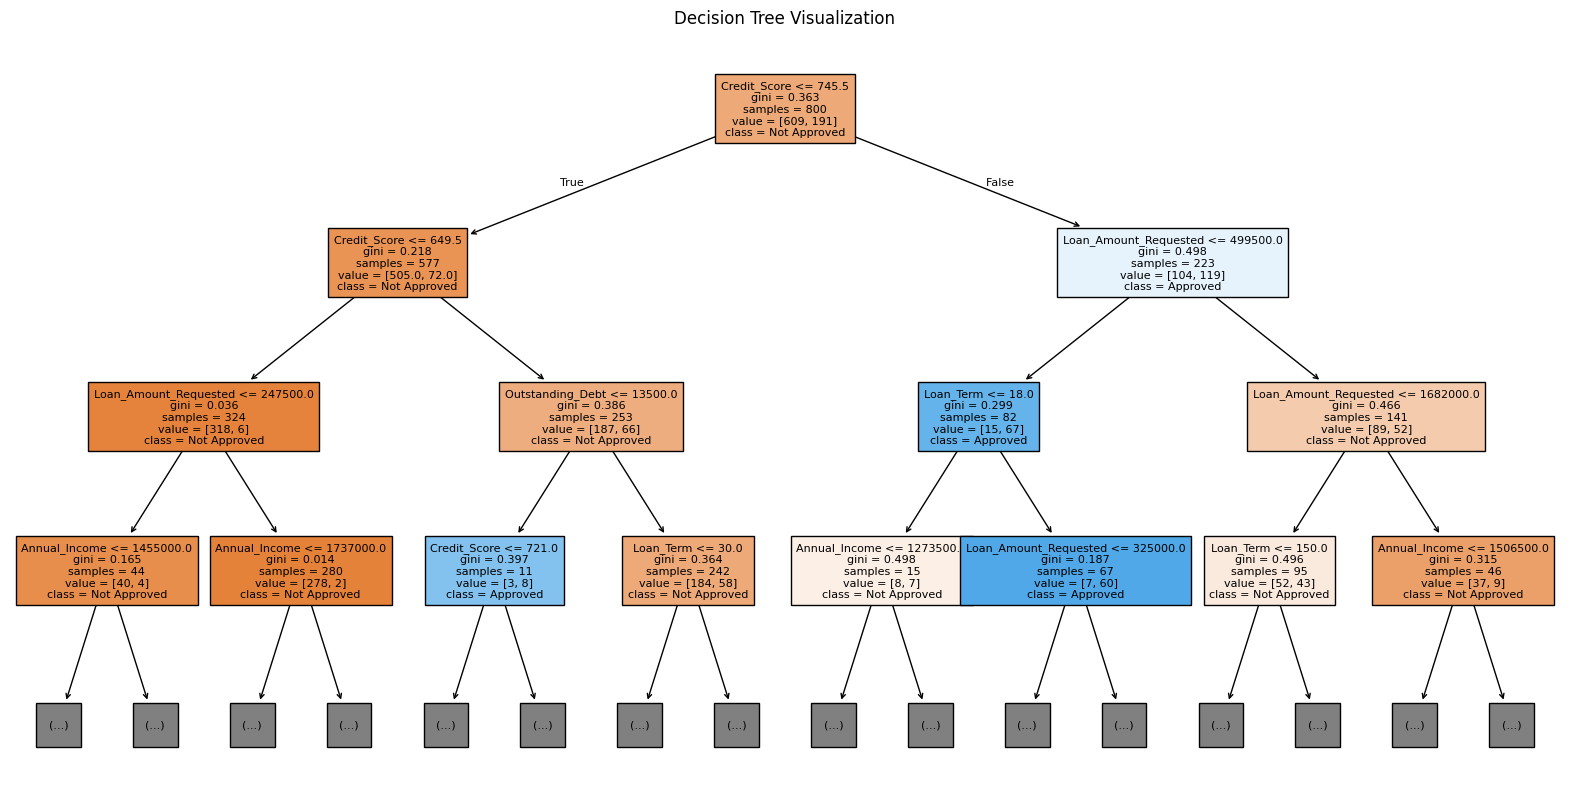

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree( dt_model, feature_names=X.columns, class_names=["Not Approved", "Approved"], filled=True, max_depth=3, fontsize=8 )
plt.title("Decision Tree Visualization")
plt.show()
# max_depth=3 is only used here so that the graph is readable. The actual model still contains the full tree.

In [ ]:
# This shows which features contributed most to the Decision Tree.
feature_importance = pd.DataFrame({ "Feature": X.columns, "Importance": dt_model.feature_importances_ })
feature_importance = feature_importance.sort_values( by="Importance", ascending=False )
print(feature_importance)

                  Feature  Importance
3            Credit_Score    0.304215
1   Loan_Amount_Requested    0.176516
0           Annual_Income    0.162862
4        Monthly_Expenses    0.099912
2               Loan_Term    0.094160
5        Outstanding_Debt    0.071735
10  Loan_Purpose_Personal    0.038278
12    Loan_Type_Unsecured    0.024460
8       Loan_Purpose_Gold    0.013922
11     Loan_Purpose_Study    0.010554
6             Gender_Male    0.003386
7       Loan_Purpose_Card    0.000000
9       Loan_Purpose_Home    0.000000


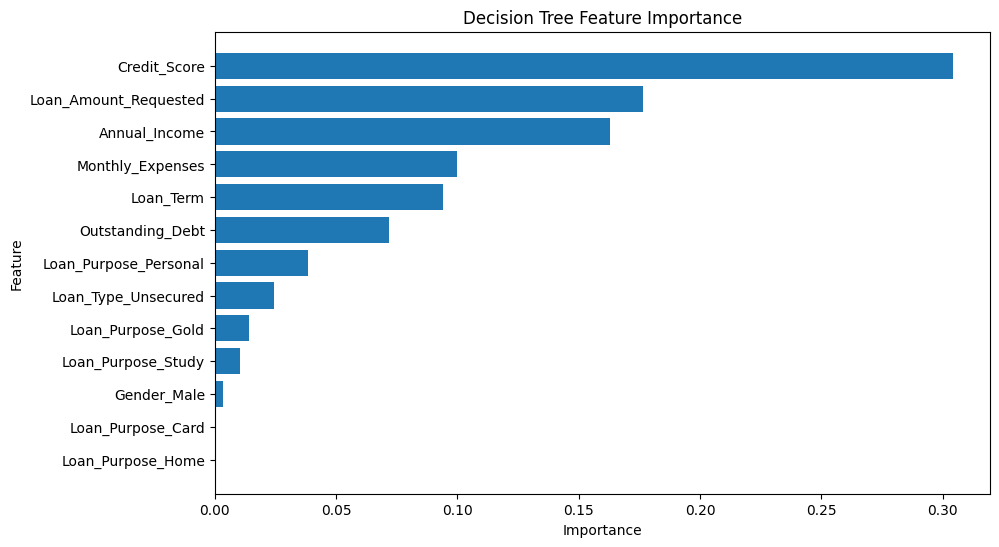

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh( feature_importance["Feature"], feature_importance["Importance"] )
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# A completely unrestricted Decision Tree can overfit the training data.

# We can control its complexity using max_depth.
depths = range(1, 16)

train_accuracies = []
test_accuracies = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracies.append(
        accuracy_score(y_train, train_pred)
    )

    test_accuracies.append(
        accuracy_score(y_test, test_pred)
    )

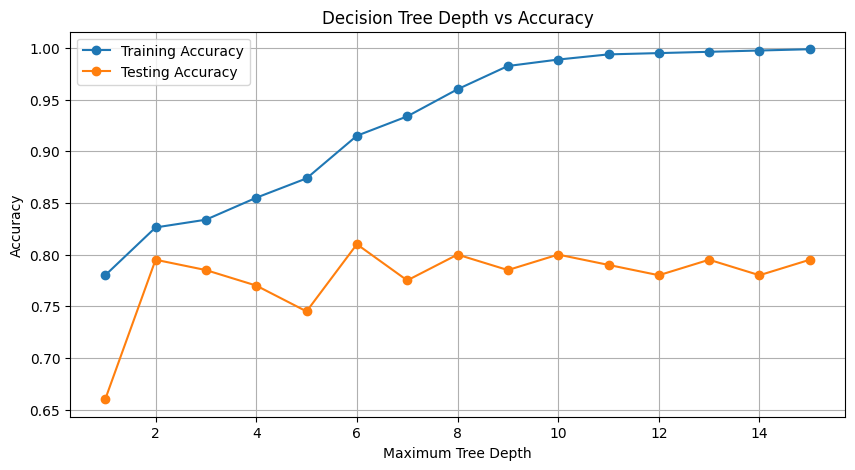

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot( depths, train_accuracies, marker="o", label="Training Accuracy" )
plt.plot( depths, test_accuracies, marker="o", label="Testing Accuracy" )
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_depth = depths[np.argmax(test_accuracies)]
best_test_accuracy = max(test_accuracies)
print("Best Tree Depth:", best_depth)
print("Best Test Accuracy:", best_test_accuracy)
print("Best Test Accuracy (%):", best_test_accuracy * 100)

Best Tree Depth: 6
Best Test Accuracy: 0.81
Best Test Accuracy (%): 81.0


In [ ]:
final_dt = DecisionTreeClassifier( max_depth=best_depth, random_state=42 )
final_dt.fit(X_train, y_train)
final_predictions = final_dt.predict(X_test)
final_accuracy = accuracy_score( y_test, final_predictions )
print("Final Decision Tree")
print("-------------------")
print("Best Depth:", best_depth)
print("Accuracy:", final_accuracy)
print("Accuracy (%):", final_accuracy * 100)

Final Decision Tree
-------------------
Best Depth: 6
Accuracy: 0.81
Accuracy (%): 81.0


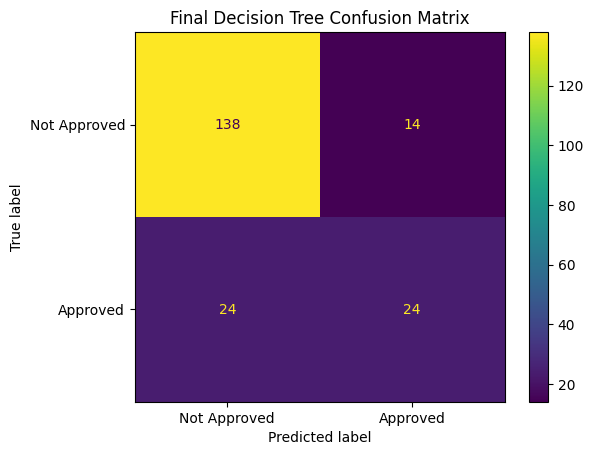

In [ ]:
final_cm = confusion_matrix( y_test, final_predictions )
disp = ConfusionMatrixDisplay( confusion_matrix=final_cm, display_labels=["Not Approved", "Approved"] )
disp.plot()
plt.title("Final Decision Tree Confusion Matrix")
plt.show()

In [ ]:
final_importance = pd.DataFrame({ "Feature": X.columns, "Importance": final_dt.feature_importances_ })
final_importance = final_importance.sort_values( by="Importance", ascending=False )
print(final_importance)

                  Feature  Importance
3            Credit_Score    0.403219
1   Loan_Amount_Requested    0.202855
0           Annual_Income    0.152624
2               Loan_Term    0.106585
4        Monthly_Expenses    0.065585
5        Outstanding_Debt    0.050163
12    Loan_Type_Unsecured    0.013796
11     Loan_Purpose_Study    0.005174
6             Gender_Male    0.000000
8       Loan_Purpose_Gold    0.000000
7       Loan_Purpose_Card    0.000000
10  Loan_Purpose_Personal    0.000000
9       Loan_Purpose_Home    0.000000


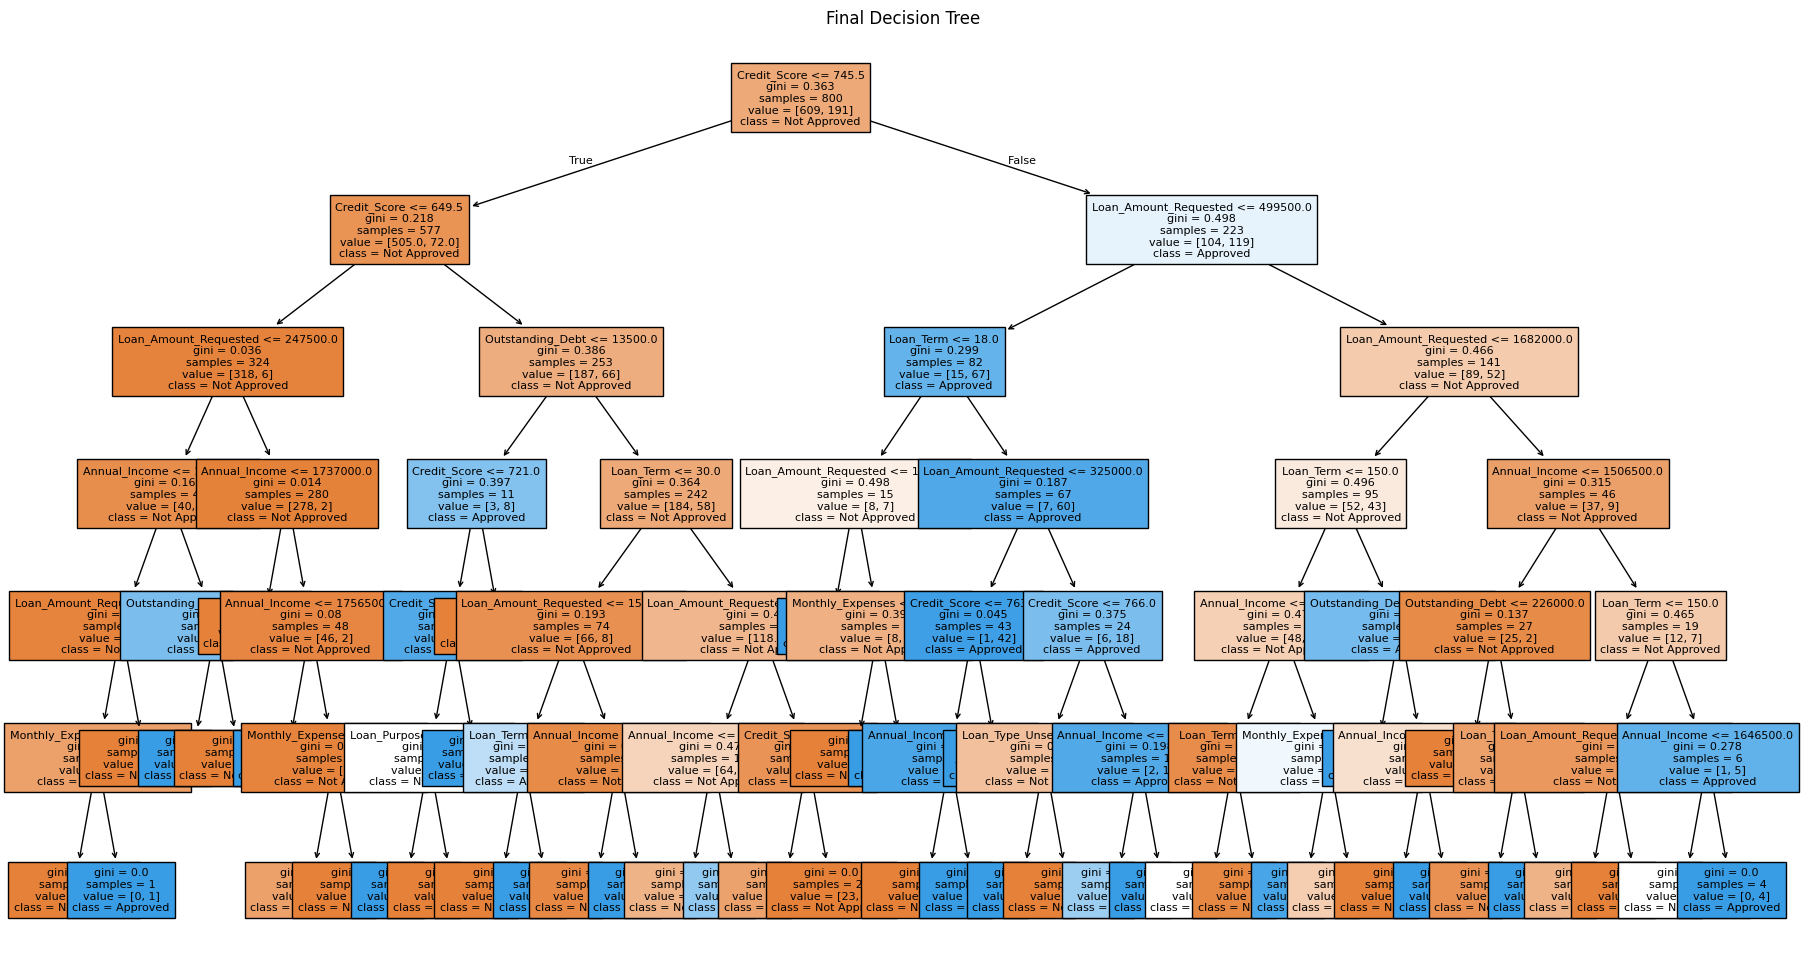

In [ ]:
plt.figure(figsize=(22, 12))
plot_tree( final_dt, feature_names=X.columns, class_names=["Not Approved", "Approved"], filled=True, fontsize=8 )
plt.title("Final Decision Tree")
plt.show()